In [1]:
from collections import Counter
from hashlib import sha256
from pathlib import Path
from zipfile import ZipFile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

In [2]:
SEED = 42

DATASET_URL = (
    "https://github.com/ultralytics/"
    "assets/releases/download/v0.0.0/"
    "crack-seg.zip"
)

DATASETS_ROOT = Path("/content/datasets")
ARCHIVE_PATH = DATASETS_ROOT / "crack-seg.zip"
DATASET_ROOT = DATASETS_ROOT / "crack-seg"

SEMANTIC_DATASET_ROOT =  DATASETS_ROOT / "crack-seg-semantic"
SEMANTIC_MASK_ROOT = SEMANTIC_DATASET_ROOT / "masks"

OUTPUT_ROOT = Path("/content/vision_unit_02_outputs/block_02")
FIGURE_ROOT = OUTPUT_ROOT / "figures"

In [ ]:
for dir in [DATASETS_ROOT, SEMANTIC_MASK_ROOT, OUTPUT_ROOT, FIGURE_ROOT]:
    dir.mkdir(parents=True, exist_ok=True)

SPLITS = ("train", "val", "test")
EXPECTED_COUNTS = {
    "train": 3717,
    "val": 200,
    "test": 112,
}

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp",
}

print("Dataset root:", DATASET_ROOT)
print("Output root:", OUTPUT_ROOT)

Dataset root: /content/datasets/crack-seg
Output root: /content/vision_unit_02_outputs/block_02


**Download and extract**


In [4]:
dataset_ready = (DATASET_ROOT / "images" / "train").is_dir()

if not dataset_ready:
    if not ARCHIVE_PATH.is_file():
        print("Downloading Crack-Seg...")
        torch.hub.download_url_to_file(
            DATASET_URL, str(ARCHIVE_PATH), progress=True
        )
        
    print("Extracting dataset...")
    with ZipFile(ARCHIVE_PATH, "r") as zip_file:
        zip_file.extractall(DATASETS_ROOT)


if not DATASET_ROOT.is_dir():
    candidates = [
        path for path in DATASETS_ROOT.rglob("*")
        if path.is_dir() and (path / "images").is_dir() and "crack" in path.name.lower()
    ]

    if len(candidates) != 1:
        candidates = [
            path for path in DATASETS_ROOT.rglob("images")
            if path.is_dir()
        ]
        if len(candidates) == 1:
            candidates = [candidates[0].parent]

    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Could not locate Crack-Seg root in {DATASETS_ROOT}. "
            f"Found candidates: {candidates}"
        )

    DATASET_ROOT = candidates[0]

100%|██████████| 91.6M/91.6M [00:02<00:00, 39.3MB/s]


Extracting dataset...


In [5]:
for split in SPLITS:
    required_directories = [
        (DATASET_ROOT / "images" / split),
        (DATASET_ROOT / "labels" / split)
    ]
    
    for directory in (required_directories):
        if not directory.is_dir():
            raise FileExistsError(directory)

print("Dataset extracted:", DATASET_ROOT)

Dataset extracted: /content/datasets


### YOLO segmentation label format

**Collect files and pairing audit**


In [6]:
def collect_images(directory):
    return sorted(
        path for path in directory.rglob("*")
        if (path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)
    )

def relative_key(file_path, root):
    return (
        file_path.relative_to(root).with_suffix("").as_posix()
    )

In [7]:
count_row = []
pairing_issue_rows = []

for split in SPLITS:
    image_root = DATASET_ROOT / "images" / split
    label_root = DATASET_ROOT / "labels" / split
    
    image_paths = collect_images(image_root)
    label_paths = sorted(label_root.rglob("*.txt"))
    
    image_keys = {
        relative_key(path, image_root) for path in image_paths
    }
    label_keys = {
        relative_key(path, label_root) for path in label_paths
    }
    
    missing_labels = sorted(image_keys - label_keys)
    orphan_labels = sorted(label_keys - image_keys)
    
    for key in missing_labels:
        pairing_issue_rows.append({
            "split" : split,
            "key" : key,
            "issue" : "missing_label"
        })
        
    for key in orphan_labels:
        pairing_issue_rows.append({
            "split" : split,
            "key" : key,
            "issue" : "orphan_label"
        })
    
    count_row.append({
        "split" : split,
        "expected_images": EXPECTED_COUNTS[split],
        "actual_images" : len(image_paths),
        "label_files" : len(label_paths),
        "missing_labels" : len(missing_labels),
        "orphan_labels" : len(orphan_labels)
    })

In [8]:
count_dataframe = pd.DataFrame(count_row)

display(count_dataframe)
count_dataframe.to_csv(OUTPUT_ROOT / "dataset_counts.csv", index=False)

,split,expected_images,actual_images,label_files,missing_labels,orphan_labels
0,train,3717,3717,3717,0,0
1,val,200,200,200,0,0
2,test,112,112,112,0,0


**Polygon parser**


In [9]:
def normalized_polygon_area(points):
    x_coordinates = points[:, 0]
    y_coordinates = points[:, 1]
    
    forward = np.dot(x_coordinates, np.roll(y_coordinates, -1))
    backward = np.dot(y_coordinates, np.roll(x_coordinates, -1))
    
    return float(0.5 * abs(forward - backward))

In [10]:
def parse_yolo_segmentation_label(label_path):
    instances = []
    issues = []
    
    if not label_path.is_file():
        return isinstance, [{
            "line" : None,
            "issue" : "missing_labels",
            "deatils" : str(label_paths)
        }]
    
    raw_lines = label_path.read_text(encoding="utf-8").splitlines()
    nonempty_lines = [line.strip() for line in raw_lines if line.strip()]
    
    for line_number, line in enumerate(nonempty_lines, start=1):
        tokens = line.split()
        
        # class + minimum 3 (x,y) points
        if len(tokens) < 7:
            issues.append({
                "line" : line_number,
                "issue" : "too_few_values",
                "detail" : len(tokens)
            })
            continue
        
        coordinate_count = len(tokens) - 1
        
        if coordinate_count % 2 != 0:
            issues.append({
                "line": line_number,
                "issue": "odd_coordinate_count",
                "detail": coordinate_count
            })
            continue
        
        try:
            class_value = float(tokens[0])
            coordinates = np.array(tokens[1:], dtype=np.float32)
        
        except ValueError:
            issues.append({
                "line": line_number,
                "issue": "non_numeric_value",
                "detail": line[:100],
            })
            continue
        
        if not class_value.is_integer():
            issues.append({
                "line": line_number,
                "issue": "non_integer_class",
                "detail": class_value,
            })
            continue
        
        class_id = int(class_value)
        if class_id != 0:
            issues.append({
                "line": line_number,
                "issue": "unknown_class",
                "detail": class_id,
            })
            continue
        
        if not np.isfinite(coordinates).all():
            issues.append({
                "line": line_number,
                "issue": "non_finite_coordinate",
                "detail": "",
            })
            continue
        
        if not((coordinates >= 0.0).all() and (coordinates <= 1.0).all()):
            issues.append({
                "line": line_number,
                "issue": "coordinate_out_of_range",
                "detail" : (
                    f"min={coordinates.min()}, "
                    f"max={coordinates.max()}"
                ),
            })
            continue
        
        points = coordinates.reshape(-1, 2)
        unique_points = np.unique(points, axis=0)
        
        if len(unique_points) < 3:
            issues.append({
                "line": line_number,
                "issue": (
                    "fewer_than_3_"
                    "unique_points"
                ),
                "detail": len(unique_points)
            })
            continue
        
        polygon_area = normalized_polygon_area(points)
        if polygon_area <= 1e-10:
            issues.append({
                "line": line_number,
                "issue": "zero_area_polygon",
                "detail": polygon_area,
            })
            continue
        
        instances.append({
            "class_id" : class_id,
            "points": points,
            "normalized_area": polygon_area
        })
        
    return instances, issues

**Full annotation audit**


In [11]:
audit_rows = []
annotation_issue_rows = []

for split in SPLITS:
    image_root = DATASET_ROOT / "images" / split
    label_root = DATASET_ROOT / "labels" / split
    
    image_paths = collect_images(image_root)
    
    for image_path in tqdm(image_paths, desc=f"Auditing {split}"):
        relative_path = image_path.relative_to(image_root)
        label_path = (label_root / relative_path).with_suffix(".txt")
        
        image = cv2.imread(str(image_path))
        
        if image is None:
            annotation_issue_rows.append({
                "split": split,
                "image": str(relative_path),
                "label": str(label_path),
                "line": None,
                "issue": "unreadable_image",
                "detail": "",
            })
            continue
        
        height, width = image.shape[:2]
        instances, issues = parse_yolo_segmentation_label(label_path)
        
        for issue in issues:
            annotation_issue_rows.append({
                "split": split,
                "image": str(relative_path),
                "label": str(label_path),
                **issue,
            })
        
        total_vertices = sum(len(instance["points"]) for instance in instances)
        
        normalized_area_sum = sum(instance["normalized_area"] for instance in instances)
        
        audit_rows.append({
            "split": split,
            "relative_image": str(relative_path),
            "image_path": str(image_path),
            "label_path": str(label_path),
            "width": width,
            "height": height,
            "instances": len(instances),
            "total_vertices": (total_vertices),
            "polygon_area_sum": (normalized_area_sum),
            "empty_label": (len(instances) == 0)
        })

Auditing train:   0%|          | 0/3717 [00:00<?, ?it/s]

Auditing val:   0%|          | 0/200 [00:00<?, ?it/s]

Auditing test:   0%|          | 0/112 [00:00<?, ?it/s]

In [12]:
audit_dataframe = pd.DataFrame(audit_rows)

annotation_issues_dataframe = pd.DataFrame(annotation_issue_rows)

pairing_issues_dataframe = pd.DataFrame(pairing_issue_rows)


audit_dataframe.to_csv(
    OUTPUT_ROOT
    / "annotation_audit.csv",
    index=False,
)

annotation_issues_dataframe.to_csv(
    OUTPUT_ROOT
    / "annotation_issues.csv",
    index=False,
)

pairing_issues_dataframe.to_csv(
    OUTPUT_ROOT
    / "pairing_issues.csv",
    index=False,
)

In [13]:
audit_summary_dataframe = (
    audit_dataframe.groupby("split")
    .agg(
        images=("relative_image", "count"),
        total_instances=("instances", "sum"),
        mean_instances=("instances", "mean"),
        max_instances=("instances", "max"),
        empty_labels=("empty_label", "sum"),
        min_width=("width", "min"),
        max_width=("width", "max"),
        min_height=("height", "min"),
        max_height=("height", "max"),
    )
    .reset_index()
)

display(audit_summary_dataframe.round(4))

print("Pairing issues:", len(pairing_issues_dataframe))
print("Annotation issues:", len(annotation_issues_dataframe))

,split,images,total_instances,mean_instances,max_instances,empty_labels,min_width,max_width,min_height,max_height
0,test,112,148,1.3214,5,0,416,416,416,416
1,train,3717,4893,1.3164,18,0,416,416,416,416
2,val,200,249,1.2450,9,1,416,416,416,416


Pairing issues: 0
Annotation issues: 0


**Rasterization functions**


In [14]:
def denornalize_polygon(normalized_points, width, height):
    pixel_points = np.empty_like(normalized_points, dtype=np.float32)
    
    pixel_points[:, 0] = normalized_points[:, 0] * width
    pixel_points[:, 1] = normalized_points[:, 1] * height
    
    pixel_points[:, 0] = np.clip(np.rint(pixel_points[:, 0]), 0, width - 1)
    pixel_points[:, 1] = np.clip(np.rint(pixel_points[:, 1]), 0, height - 1)
    
    return pixel_points.astype(np.int32)

In [15]:
def instances_to_semantic_mask(instances, width, height):
    semantic_mask = np.zeros((height, width), dtype=np.uint8)
    
    for instance in instances:
        pixel_points = denornalize_polygon(
            instance["points"], width, height
        )
        cv2.fillPoly(semantic_mask, [pixel_points], color=1)

    return semantic_mask

**Stop gate before conversion**


In [16]:
blocking_issue_count = len(pairing_issues_dataframe) + len(annotation_issues_dataframe)

if blocking_issue_count > 0:
    raise RuntimeError(
        "Dataset audit found "
        f"{blocking_issue_count} issues"
        "Inspect before conversion."
    )

print("Annotation audit passed")

Annotation audit passed


**Generate semantic PNG masks**


In [17]:
mask_records = []

for split in SPLITS:
    split_rows = audit_dataframe[audit_dataframe["split"] == split]
    
    for row in tqdm(split_rows.itertuples(index=False), total=len(split_rows), desc=f"Converting {split}"):
        
        image_path = Path(row.image_path)
        label_path = Path(row.label_path)
        image_root = DATASET_ROOT / "images" / split

        relative_image = image_path.relative_to(image_root)
        output_mask_path = (SEMANTIC_MASK_ROOT / split / relative_image).with_suffix(".png")
        
        output_mask_path.parent.mkdir(parents=True, exist_ok=True)
        
        instances, issues = parse_yolo_segmentation_label(label_path)
        
        if issues:
            raise RuntimeError(
                f"Unexpected label issue: "
                f"{label_path}"
            )
        
        semantic_mask = instances_to_semantic_mask(instances, width=row.width, height=row.height)
        
        saved = cv2.imwrite(str(output_mask_path), semantic_mask)
        
        if not saved:
            raise IOError(
                f"Could not save "
                f"{output_mask_path}"
            )
            
        crack_pixels = int(semantic_mask.sum())
        total_pixels = int(semantic_mask.size)
        
        mask_records.append({
            "split": split,
            "relative_image": str(relative_image),
            "image_path": str(image_path),
            "mask_path": str(output_mask_path),
            "width": row.width,
            "height": row.height,
            "instances": (row.instances),
            "crack_pixels": (crack_pixels),
            "total_pixels": (total_pixels),
            "crack_ratio": (crack_pixels / total_pixels)
        })

Converting train:   0%|          | 0/3717 [00:00<?, ?it/s]

Converting val:   0%|          | 0/200 [00:00<?, ?it/s]

Converting test:   0%|          | 0/112 [00:00<?, ?it/s]

In [18]:
mask_manifest_dataframe = pd.DataFrame(mask_records)
mask_manifest_path = OUTPUT_ROOT / "semantic_mask_manifest.csv"


mask_manifest_dataframe.to_csv(
    mask_manifest_path, index=False
)

print("Manifest:", mask_manifest_path)

Manifest: /content/vision_unit_02_outputs/block_02/semantic_mask_manifest.csv


**Verify every saved mask**

In [19]:
mask_integrity_issues = []

for row in tqdm(mask_manifest_dataframe.itertuples(index=False), total=len(mask_manifest_dataframe), desc="Checking masks"):
    mask = cv2.imread(row.mask_path, cv2.IMREAD_UNCHANGED)
    
    if mask is None:
        mask_integrity_issues.append({
            "split": row.split,
            "image": row.relative_image,
            "issue": "unreadable_mask",
        })
        continue
    
    expected_shape = (row.height, row.width)
    if mask.shape != expected_shape:
        mask_integrity_issues.append({
            "split": row.split,
            "image": (
                row.relative_image
            ),
            "issue": (
                "shape_mismatch"
            ),
            "detail": (
                f"{mask.shape} vs "
                f"{expected_shape}"
            ),
        })
    
    unique_values = set(np.unique(mask).tolist())
    if not unique_values.issubset({0, 1}):
        mask_integrity_issues.append({
            "split": row.split,
            "image": row.relative_image,
            "issue": "invalid_mask_values",
            "detail": str(unique_values),
        })

Checking masks:   0%|          | 0/4029 [00:00<?, ?it/s]

In [20]:
mask_integrity_dataframe = pd.DataFrame(mask_integrity_issues)

mask_integrity_dataframe.to_csv(
    OUTPUT_ROOT
    / "mask_integrity_issues.csv",
    index=False,
)

print("Mask integrity issues:", len(mask_integrity_dataframe))

Mask integrity issues: 0


**Train/validation mask statistics**

In [22]:
analysis_dataframe = mask_manifest_dataframe[mask_manifest_dataframe["split"].isin(["train", "val"])].copy()

def mask_size_category(crack_ratio):
    if crack_ratio == 0:
        return "empty"
    if crack_ratio < 0.005:
        return "tiny_<0.5%"
    if crack_ratio < 0.02:
        return "small_0.5-2%"
    if crack_ratio < 0.10:
        return "medium_2-10%"
    return "large_>=10"

analysis_dataframe["mask_size"] = analysis_dataframe["crack_ratio"].apply(mask_size_category)

In [23]:
statistics_rows = []

for split in ["train", "val"]:
    split_data = analysis_dataframe[analysis_dataframe["split"] == split]
    
    statistics_rows.append({
        "split": split,
        "images": len(split_data),
        "total_instances" : int(
            split_data["instances"].sum()
        ),
        "empty_mask" : int(
            (split_data["crack_pixels"] == 0).sum()
        ),
        "mean_crack_ratio": float(
            split_data["crack_ratio"].mean()
        ),
        "median_crack_ratio": float(
            split_data["crack_ratio"].median()
        ),
        "p10_crack_ratio": float(
            split_data["crack_ratio"].quantile(0.10)
        ),
        "p90_crack_ratio": float(
            split_data["crack_ratio"].quantile(0.90)
        ),
    })

In [24]:
statistics_dataframe = pd.DataFrame(statistics_rows)
display(statistics_dataframe.round(6))

statistics_dataframe.to_csv(
    OUTPUT_ROOT
    / "mask_statistics.csv",
    index=False,
)

,split,images,total_instances,empty_mask,mean_crack_ratio,median_crack_ratio,p10_crack_ratio,p90_crack_ratio
0,train,3717,4893,0,0.021648,0.018087,0.008356,0.039802
1,val,200,249,1,0.020265,0.016807,0.007324,0.034712


In [25]:
mask_size_dataframe = analysis_dataframe.groupby(["split", "mask_size"], observed=False).size().unstack(fill_value=0)

display(mask_size_dataframe)

mask_size_dataframe.to_csv(
    OUTPUT_ROOT
    / "mask_size_distribution.csv"
)

mask_size,empty,large_>=10,medium_2-10%,small_0.5-2%,tiny_<0.5%
split,,,,,
train,0,6,1597,2073,41
val,1,0,79,118,2


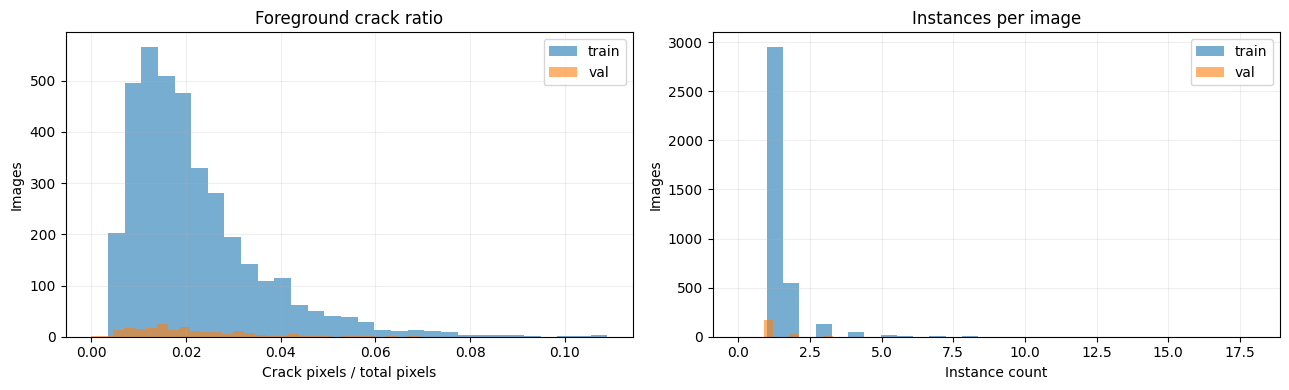

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for split in ["train", "val"]:
    split_data = (
        analysis_dataframe[
            analysis_dataframe["split"] == split
        ]
    )

    axes[0].hist(
        split_data["crack_ratio"], bins=30, 
        alpha=0.6, label=split,
    )

    axes[1].hist(
        split_data["instances"],bins=30, 
        alpha=0.6, label=split,
    )

axes[0].set_title("Foreground crack ratio")
axes[0].set_xlabel("Crack pixels / total pixels")

axes[1].set_title("Instances per image")
axes[1].set_xlabel("Instance count")

for axis in axes:
    axis.set_ylabel("Images")
    axis.legend()
    axis.grid(alpha=0.2)

plt.tight_layout()
statistics_figure_path = FIGURE_ROOT / "mask_statistics.png"

plt.savefig(
    statistics_figure_path,
    dpi=180, bbox_inches="tight",
)
plt.show()

**Polygon and semantic-mask visualization**

In [27]:
INSTANCE_COLORS = np.array([
    [255, 70, 70],
    [70, 220, 100],
    [70, 140, 255],
    [240, 190, 60],
    [190, 80, 230],
], dtype=np.uint8)

def create_instance_overlay(image_rgb, instances):
    output = image_rgb.copy()
    height, width = image_rgb.shape[:2]
    
    for index, instance in enumerate(instances):
        color = INSTANCE_COLORS[index % len(INSTANCE_COLORS)]
        
        points = denornalize_polygon(instance["points"], width, height)
        region = np.zeros((height, width), dtype=np.uint8)
        
        cv2.fillPoly(region, [points], color=1)
        foreground = region.astype(bool)
        
        output[foreground] = (0.55 * output[foreground] + 0.45 * color).astype(np.uint8)
        
        cv2.polylines(
            output, [points],
            isClosed=True,
            color=tuple(int(value) for value in color),
            thickness=2
        )

    return output

In [28]:
def create_semantic_overlay(image_rgb, semantic_mask):
    output = image_rgb.copy()
    foreground = semantic_mask == 1
    crack_color = np.array(
        [255, 40, 40],
        dtype=np.uint8,
    )

    output[foreground] = (
        0.55
        * output[foreground]
        + 0.45
        * crack_color
    ).astype(np.uint8)

    return output

In [29]:
sample_rows = []

for offset, split in enumerate(["train", "val",]):
    split_data = (
        mask_manifest_dataframe[
            mask_manifest_dataframe["split"] == split
        ]
    )

    selected = split_data.sample(
        n=min(3, len(split_data)),
        random_state=(SEED + offset)
    )
    sample_rows.append(selected)


sample_dataframe = pd.concat(
    sample_rows, ignore_index=True
)

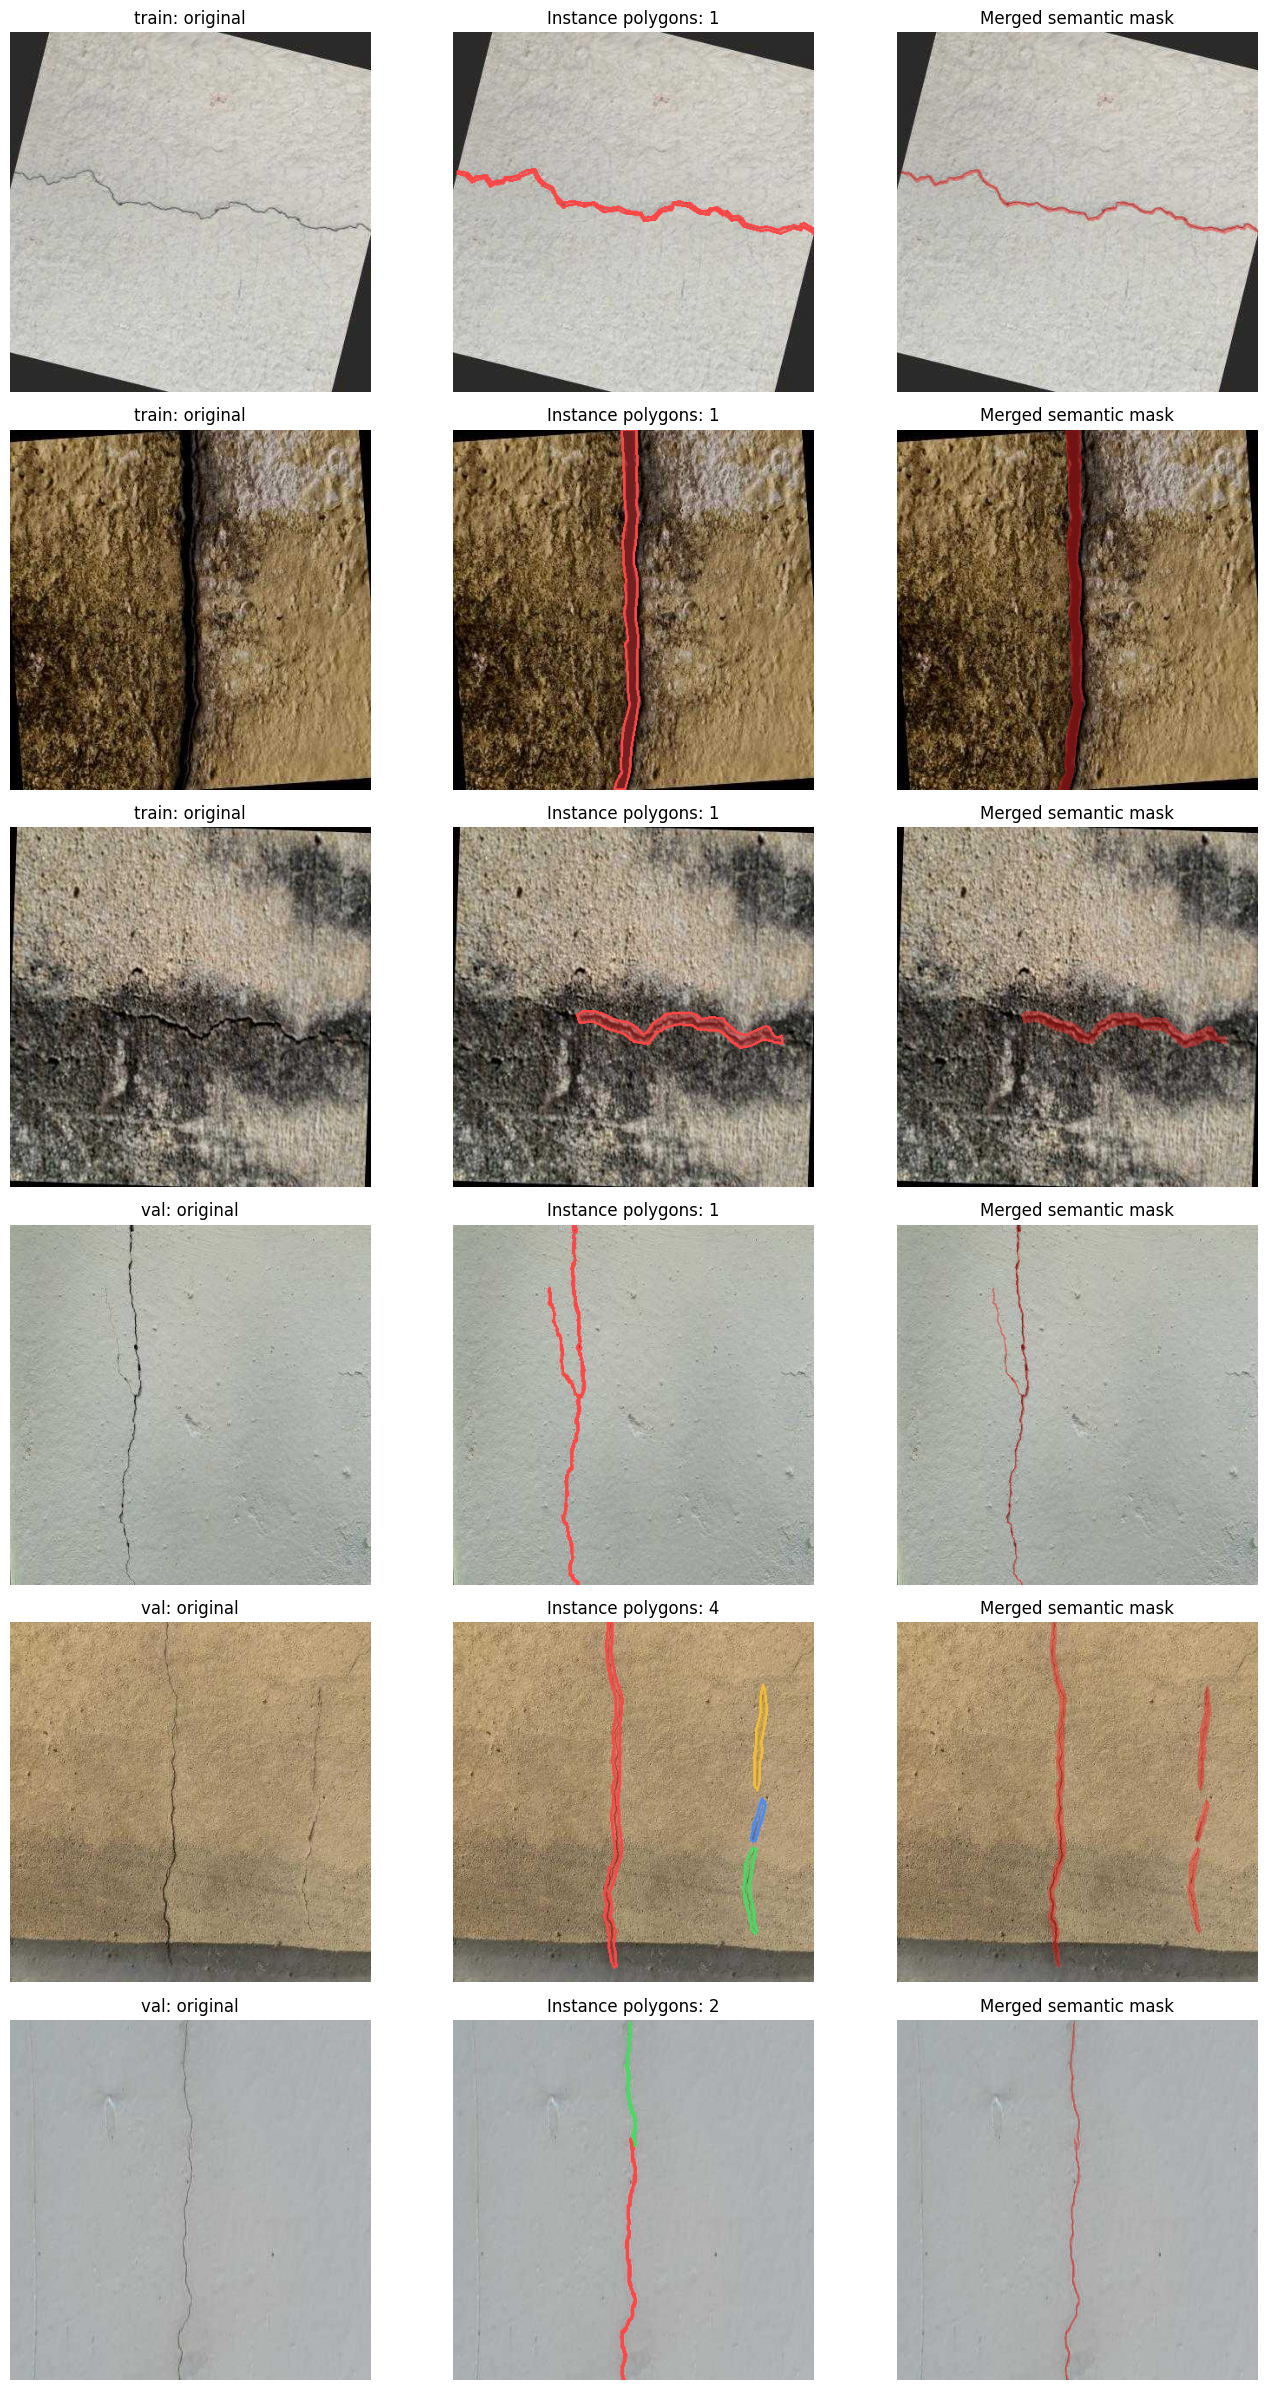

In [30]:
figure, axes = plt.subplots(
    len(sample_dataframe), 3,
    figsize=(14, 4 * len(sample_dataframe)),
)

for row_index, row in enumerate(sample_dataframe.itertuples(index=False)):
    image_bgr = cv2.imread(row.image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    semantic_mask = cv2.imread(row.mask_path, cv2.IMREAD_UNCHANGED)

    label_path = (
        DATASET_ROOT / "labels" / row.split / Path(row.relative_image)
    ).with_suffix(".txt")

    instances, issues = parse_yolo_segmentation_label(label_path)

    if issues:
        raise RuntimeError(label_path)

    instance_overlay = create_instance_overlay(image_rgb, instances)
    semantic_overlay = create_semantic_overlay(image_rgb, semantic_mask)

    axes[row_index, 0].imshow(image_rgb)
    axes[row_index, 0].set_title(f"{row.split}: original")

    axes[row_index, 1].imshow(instance_overlay)
    axes[row_index, 1].set_title(f"Instance polygons: {len(instances)}")

    axes[row_index, 2].imshow(semantic_overlay)
    axes[row_index, 2].set_title("Merged semantic mask")

    for axis in axes[row_index]:
        axis.axis("off")

plt.tight_layout()

sample_figure_path = FIGURE_ROOT / "annotation_and_masks.png"
plt.savefig(sample_figure_path, dpi=180, bbox_inches="tight")
plt.show()